# Experiment2: Develop a LSTM-based model for time series data forecasting.

Use Electricity Transformer Temperature Dataset downloadable from Hithub/Kaggle.

In [77]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tarit21/electricity-transformer-dataset-etdataset")

print("Path to dataset files:", path)

Path to dataset files: /home/rito/.cache/kagglehub/datasets/tarit21/electricity-transformer-dataset-etdataset/versions/1


In [101]:
seq_length = 128
batch_size = 10
learning_rate = 0.0001
num_epochs = 50

In [79]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

In [80]:
os.listdir(path + "/ETT-small")
path_data = path + "/ETT-small"

In [81]:
data = pd.read_csv(path_data + "/ETTh1.csv")

In [82]:
data

,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
1,2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2,2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
3,2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
4,2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000
...,...,...,...,...,...,...,...,...
17415,2018-06-26 15:00:00,-1.674,3.550,-5.615,2.132,3.472,1.523,10.904000
17416,2018-06-26 16:00:00,-5.492,4.287,-9.132,2.274,3.533,1.675,11.044000
17417,2018-06-26 17:00:00,2.813,3.818,-0.817,2.097,3.716,1.523,10.271000
17418,2018-06-26 18:00:00,9.243,3.818,5.472,2.097,3.655,1.432,9.778000


In [83]:
df = pd.DataFrame(data)

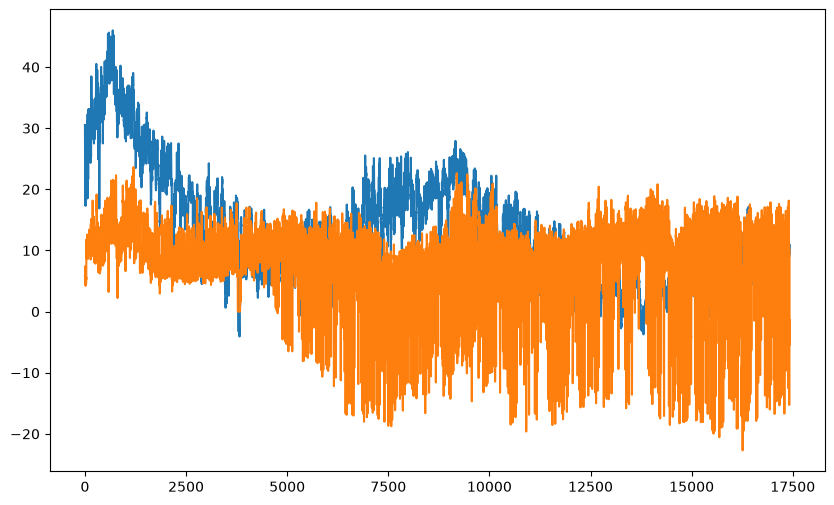

In [84]:
plt.figure(figsize=(10,6))
plt.plot(df.OT)
plt.plot(df.HUFL)
plt.show()

In [85]:
# Check dataset size
print("Total samples:", len(df))

# Chronological split
train_size = int(len(df) * 0.70)
val_size = int(len(df) * 0.15)

train = df.iloc[:train_size]
val = df.iloc[train_size:train_size + val_size]
test = df.iloc[train_size + val_size:]

print("Train:", train.shape)
print("Validation:", val.shape)
print("Test:", test.shape)

Total samples: 17420
Train: (12194, 8)
Validation: (2613, 8)
Test: (2613, 8)


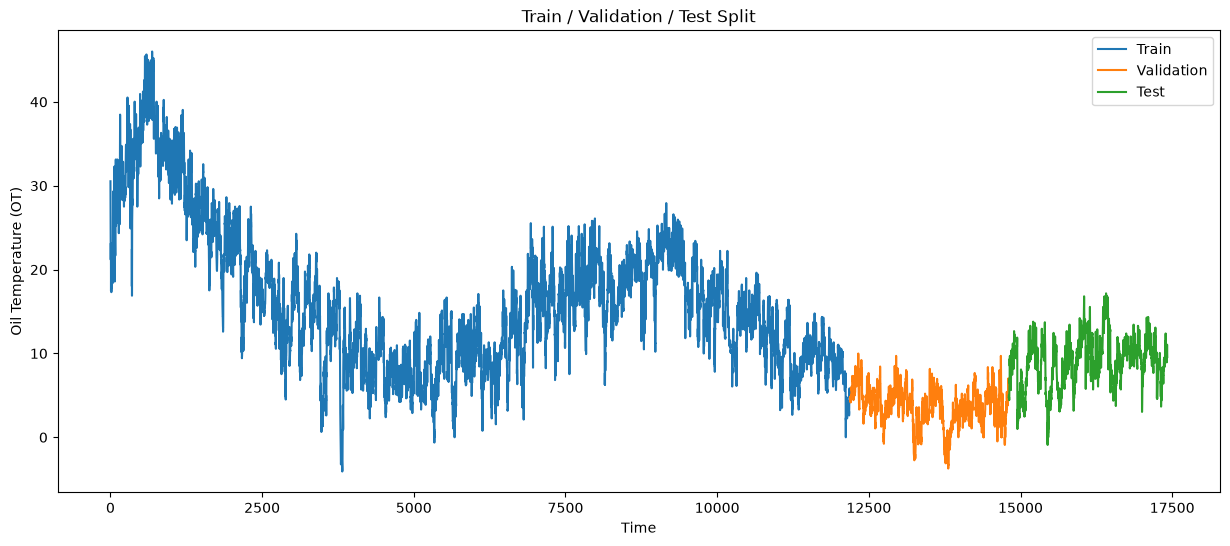

In [86]:
plt.figure(figsize=(15, 6))

plt.plot(train['OT'], label='Train')
plt.plot(val['OT'], label='Validation')
plt.plot(test['OT'], label='Test')

plt.xlabel('Time')
plt.ylabel('Oil Temperature (OT)')
plt.title('Train / Validation / Test Split')
plt.legend()
plt.show()

In [87]:
from sklearn.preprocessing import MinMaxScaler

features = ['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL']
target = 'OT'

feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

# Training data: learn min/max AND scale
X_train = feature_scaler.fit_transform(train[features])
y_train = target_scaler.fit_transform(train[[target]])

# Validation/test: use the min/max learned from training
X_val = feature_scaler.transform(val[features])
y_val = target_scaler.transform(val[[target]])

X_test = feature_scaler.transform(test[features])
y_test = target_scaler.transform(test[[target]])

In [88]:
def create_sequences(X, y, seq_length):
    X_seq = []
    y_seq = []

    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i + seq_length])
        y_seq.append(y[i + seq_length])

    return np.array(X_seq), np.array(y_seq)

In [89]:
def create_sequences(X, y, seq_length):
    X_seq = []
    y_seq = []

    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i + seq_length])
        y_seq.append(y[i + seq_length])

    return np.array(X_seq), np.array(y_seq)

In [90]:
# seq_length = 24

X_train_seq, y_train_seq = create_sequences(
    X_train, y_train, seq_length
)

X_val_seq, y_val_seq = create_sequences(
    X_val, y_val, seq_length
)

X_test_seq, y_test_seq = create_sequences(
    X_test, y_test, seq_length
)

print(X_train_seq.shape)
print(y_train_seq.shape)

(12066, 128, 6)
(12066, 1)


In [91]:
X_train_seq[0][0]

array([0.58822715, 0.45494283, 0.5994606 , 0.47367253, 0.5565765 ,
       0.61376501])

In [92]:
import torch

X_train_tensor = torch.tensor(X_train_seq, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_seq, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val_seq, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_seq, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_seq, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_seq, dtype=torch.float32)

In [93]:
from torch.utils.data import TensorDataset, DataLoader

# batch_size = 10

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [94]:
import torch.nn as nn

class LSTMModel(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size,
        num_layers,
        output_size
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden_size,
            output_size
        )

    def forward(self, x):

        out, (hidden, cell) = self.lstm(x)

        # Take the last time step
        out = out[:, -1, :]

        # Convert hidden representation to OT prediction
        out = self.fc(out)

        return out

In [95]:
model = LSTMModel(
    input_size=6,
    hidden_size=64,
    num_layers=2,
    output_size=1
)

print(model)

LSTMModel(
  (lstm): LSTM(6, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [99]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate
)

In [102]:
# num_epochs = 40

train_losses = []
val_losses = []

for epoch in range(num_epochs):

    # --------------------
    # Training
    # --------------------
    model.train()

    train_loss = 0.0

    for X_batch, y_batch in train_loader:

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        predictions = model(X_batch)

        # Calculate loss
        loss = criterion(predictions, y_batch)

        # Backpropagation
        loss.backward()

        # Update model weights
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)


    # --------------------
    # Validation
    # --------------------
    model.eval()

    val_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            predictions = model(X_batch)

            loss = criterion(predictions, y_batch)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.6f} "
        f"Val Loss: {val_loss:.6f}"
    )

Epoch [1/50] Train Loss: 0.009658 Val Loss: 0.007298
Epoch [2/50] Train Loss: 0.011656 Val Loss: 0.007556
Epoch [3/50] Train Loss: 0.011543 Val Loss: 0.008388


KeyboardInterrupt: 

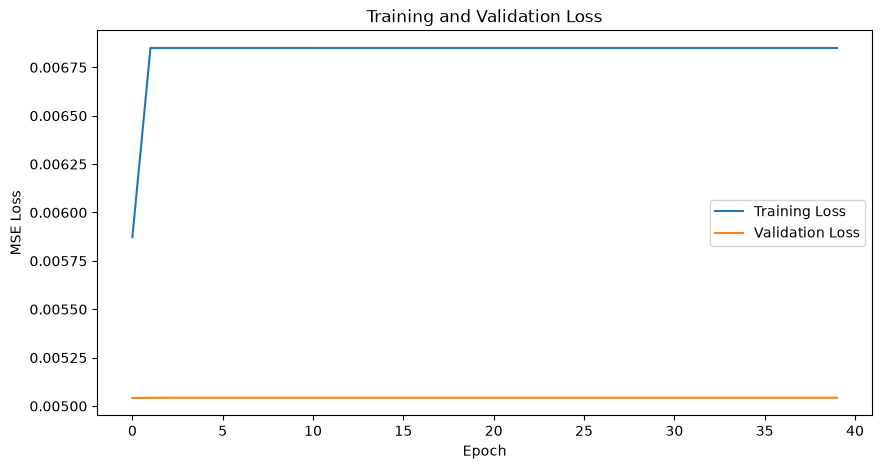

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss')

plt.legend()
plt.show()

In [ ]:
model.eval()

predictions = []
actuals = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        y_pred = model(X_batch)

        predictions.extend(y_pred.numpy())
        actuals.extend(y_batch.numpy())

In [ ]:
predictions = np.array(predictions)
actuals = np.array(actuals)

print(predictions.shape)
print(actuals.shape)

(2589, 1)
(2589, 1)


In [ ]:
predictions_original = target_scaler.inverse_transform(predictions)
actuals_original = target_scaler.inverse_transform(actuals)

In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    actuals_original,
    predictions_original
)

print("MAE:", mae)

MAE: 3.1983489990234375


In [ ]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(
    mean_squared_error(
        actuals_original,
        predictions_original
    )
)

print("RMSE:", rmse)

RMSE: 3.7898146050031802


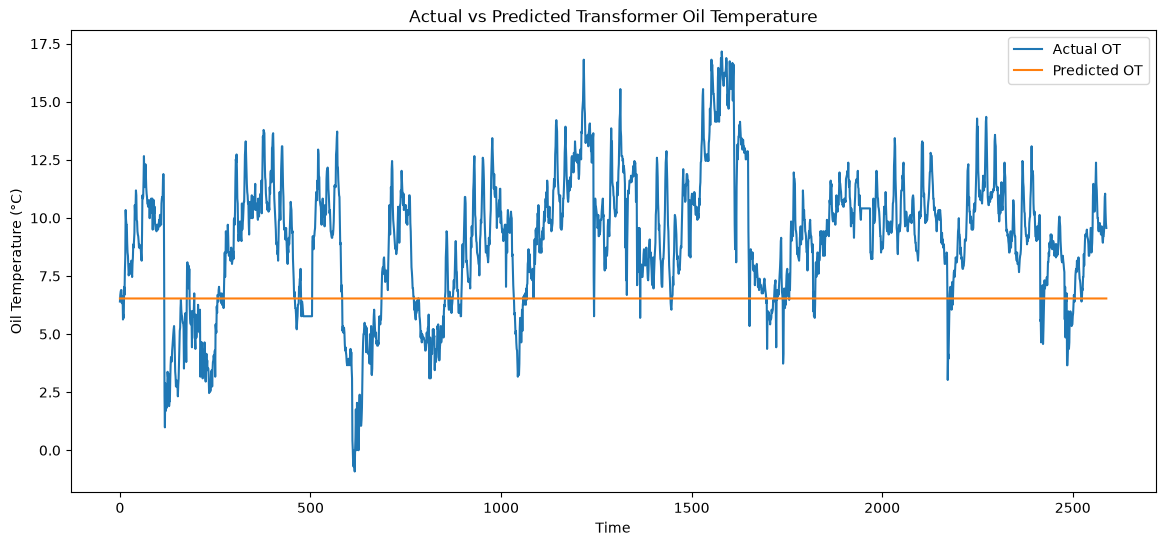

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    actuals_original,
    label='Actual OT'
)

plt.plot(
    predictions_original,
    label='Predicted OT'
)

plt.xlabel('Time')
plt.ylabel('Oil Temperature (°C)')
plt.title('Actual vs Predicted Transformer Oil Temperature')

plt.legend()
plt.show()